In [26]:
import os

# Adjust these to match your local file structure
base_dir = r'C:\Users\mahit\Downloads\Plantseg\Plantseg'  # Modify this as needed

images_dir = os.path.join(base_dir, "images")
annotations_dir = os.path.join(base_dir, "annotations")

print("Images folder:", images_dir)
print("Masks (annotations) folder:", annotations_dir)

# Optional: check a listing
print("Sample images:", os.listdir(images_dir)[:5])
print("Sample masks:", os.listdir(annotations_dir)[:5])


Images folder: C:\Users\mahit\Downloads\Plantseg\Plantseg\images
Masks (annotations) folder: C:\Users\mahit\Downloads\Plantseg\Plantseg\annotations
Sample images: ['test', 'train', 'val']
Sample masks: ['test', 'train', 'val']


In [27]:
base_dir = r'C:\Users\mahit\Downloads\Plantseg\Plantseg'
images_dir = os.path.join(base_dir, "images")
masks_dir = os.path.join(base_dir, "annotations")

train_images = os.path.join(images_dir, "train")
val_images = os.path.join(images_dir, "val")
test_images = os.path.join(images_dir, "test")

train_masks = os.path.join(masks_dir, "train")
val_masks = os.path.join(masks_dir, "val")
test_masks = os.path.join(masks_dir, "test")


In [28]:
import os
import pandas as pd

base_dir = r'C:\Users\mahit\Downloads\Plantseg\Plantseg'
metadata_path = os.path.join(base_dir, 'Metadata.csv')

df = pd.read_csv(metadata_path)
print(df.head())
print(df.columns)


                      Name  Index  Plant          Disease Resolution  \
0    apple_black_rot_1.jpg      0  Apple  apple black rot    640x480   
1   apple_black_rot_11.jpg      0  Apple  apple black rot   1080x755   
2   apple_black_rot_12.jpg      0  Apple  apple black rot   1280x719   
3   apple_black_rot_15.jpg      0  Apple  apple black rot    600x355   
4  apple_black_rot_156.jpg      0  Apple  apple black rot    219x294   

                Label file  Mask ratio  \
0    apple_black_rot_1.png    0.040439   
1   apple_black_rot_11.png    0.057550   
2   apple_black_rot_12.png    0.024791   
3   apple_black_rot_15.png    0.236169   
4  apple_black_rot_156.png    0.054344   

                                                 URL License     Split  
0     http://www.my478.com/html/20210418/372066.html   CC-BY  Training  
1  http://dy.163.com/v2/article/detail/EJ3OGOG605...   CC-BY  Training  
2  http://baijiahao.baidu.com/s?id=16205160930871...   CC-BY  Training  
3  http://www.jnxsn.co

In [29]:
import os

split_map = {'training': 'train', 'validation': 'val', 'test': 'test'}
df['split_folder'] = df['Split'].str.lower().map(split_map)

df['image_path'] = df.apply(
    lambda row: os.path.join(base_dir, 'images', row['split_folder'], str(row['Name'])),
    axis=1
)
df['mask_path'] = df.apply(
    lambda row: os.path.join(base_dir, 'annotations', row['split_folder'], str(row['Label file'])),
    axis=1
)

print(df[['image_path', 'mask_path']].head())


                                          image_path  \
0  C:\Users\mahit\Downloads\Plantseg\Plantseg\ima...   
1  C:\Users\mahit\Downloads\Plantseg\Plantseg\ima...   
2  C:\Users\mahit\Downloads\Plantseg\Plantseg\ima...   
3  C:\Users\mahit\Downloads\Plantseg\Plantseg\ima...   
4  C:\Users\mahit\Downloads\Plantseg\Plantseg\ima...   

                                           mask_path  
0  C:\Users\mahit\Downloads\Plantseg\Plantseg\ann...  
1  C:\Users\mahit\Downloads\Plantseg\Plantseg\ann...  
2  C:\Users\mahit\Downloads\Plantseg\Plantseg\ann...  
3  C:\Users\mahit\Downloads\Plantseg\Plantseg\ann...  
4  C:\Users\mahit\Downloads\Plantseg\Plantseg\ann...  


In [30]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [31]:
from PIL import Image

def resize_image(image_path, size=(256, 256)):
    img = Image.open(image_path).convert('RGB')
    return img.resize(size, Image.LANCZOS)

def resize_mask(mask_path, size=(256, 256)):
    mask = Image.open(mask_path).convert('L')
    return mask.resize(size, Image.LANCZOS)


In [32]:
import numpy as np

def normalize_image(img):
    img_array = np.asarray(img) / 255.0  # Scale to [0,1]
    # ImageNet mean/std
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_norm = (img_array - mean) / std
    return img_norm


In [33]:
def process_mask(mask):
    mask_array = np.asarray(mask)
    # Disease pixels to 1, background to 0
    binary_mask = (mask_array > 127).astype(np.float32)  # Adjust threshold as needed
    return binary_mask


In [34]:
import os
path = os.path.join(base_dir, 'annotations', df.iloc[0]['split_folder'])
print(path)
print(os.listdir(path))



C:\Users\mahit\Downloads\Plantseg\Plantseg\annotations\train
['apple_black_rot_1.png', 'apple_black_rot_11.png', 'apple_black_rot_12.png', 'apple_black_rot_15.png', 'apple_black_rot_156.png', 'apple_black_rot_187.png', 'apple_black_rot_3.png', 'apple_black_rot_34.png', 'apple_black_rot_38.png', 'apple_black_rot_4.png', 'apple_black_rot_44.png', 'apple_black_rot_5.png', 'apple_black_rot_53.png', 'apple_black_rot_6.png', 'apple_black_rot_61.png', 'apple_black_rot_69.png', 'apple_black_rot_74.png', 'apple_black_rot_8.png', 'apple_black_rot_80.png', 'apple_black_rot_9.png', 'apple_black_rot_google_0000.png', 'apple_black_rot_google_0002.png', 'apple_black_rot_google_0003.png', 'apple_black_rot_google_0022.png', 'apple_black_rot_google_0024.png', 'apple_black_rot_google_0026.png', 'apple_black_rot_google_0028.png', 'apple_black_rot_google_0033.png', 'apple_black_rot_google_0045.png', 'apple_black_rot_google_0048.png', 'apple_black_rot_google_0050.png', 'apple_black_rot_google_0051.png', 'ap

In [35]:
!pip install tqdm


In [36]:
from tqdm import tqdm
def mask_has_content(mask_path):
    mask = np.asarray(Image.open(mask_path).convert('L'))
    return mask.max() > 0

tqdm.pandas()
df = df[df['mask_path'].progress_apply(mask_has_content)].reset_index(drop=True)


100%|███████████████████████████████████████████████████████████████████████████| 11458/11458 [01:35<00:00, 119.55it/s]


In [37]:
# Get all unique disease names
disease_classes = sorted(df['Disease'].unique())
class2idx = {c: i for i, c in enumerate(disease_classes)}
df['disease_idx'] = df['Disease'].map(class2idx)

In [38]:
# These filters use your cleaned DataFrame
train_df = df[df['split_folder'] == 'train'].reset_index(drop=True)
val_df = df[df['split_folder'] == 'val'].reset_index(drop=True)


In [39]:
from torchvision import transforms

image_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),  # ImageNet mean/std for EfficientNet/UNet
])

mask_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    # No normalization for mask; convert to binary in Dataset class
])


In [40]:
print(df.columns.tolist())

['Name', 'Index', 'Plant', 'Disease', 'Resolution', 'Label file', 'Mask ratio', 'URL', 'License', 'Split', 'split_folder', 'image_path', 'mask_path', 'disease_idx']


In [41]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import torch

# ---------- Configurable Parameters ----------
RESIZE_SHAPE = (256, 256)

# Image transform: resize, tensor, normalization
image_transforms = transforms.Compose([
    transforms.Resize(RESIZE_SHAPE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

class PlantSegmentationDataset(Dataset):
    def __init__(self, df):
        self.df = df

    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['image_path']
        mask_path = self.df.iloc[idx]['mask_path']
        label = self.df.iloc[idx]['disease_idx']

        # IMAGE PREPROCESSING
        img = Image.open(img_path).convert("RGB")
        img = image_transforms(img)

        # MASK PREPROCESSING --- force PIL resize for 100% consistency
        mask_pil = Image.open(mask_path).convert("L")
        mask_pil = mask_pil.resize(RESIZE_SHAPE, resample=Image.NEAREST)
        mask_tensor = transforms.ToTensor()(mask_pil)     # [1, H, W]
        mask_tensor = (mask_tensor > 0).float()           # binarize: 0/1 only

        return img, mask_tensor, label

# ---------- Example Usage ----------
# train_df and val_df should be DataFrames for your splits

train_dataset = PlantSegmentationDataset(train_df)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

val_dataset = PlantSegmentationDataset(val_df)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

# ---------- Debug Print ----------
img, mask, label = train_dataset[0]
print("Image shape:", img.shape)    # Should be torch.Size([3, 256, 256])
print("Mask shape:", mask.shape)    # Should be torch.Size([1, 256, 256])
print("Label:", label)


Image shape: torch.Size([3, 256, 256])
Mask shape: torch.Size([1, 256, 256])
Label: 0


In [42]:
train_df = df[df['split_folder'] == 'train'].reset_index(drop=True)
val_df = df[df['split_folder'] == 'val'].reset_index(drop=True)


In [43]:
train_dataset = PlantSegmentationDataset(train_df)
val_dataset = PlantSegmentationDataset(val_df)

from torch.utils.data import DataLoader
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)


In [44]:
from torchvision import models
import torch
import torch.nn as nn
import torch.nn.functional as F

num_classes = len(disease_classes)  # Should match your class2idx size
efficientnet = models.efficientnet_b0(weights=True)
efficientnet.classifier[1] = nn.Linear(efficientnet.classifier[1].in_features, num_classes)


C:\Users\mahit\anaconda3\envs\torch_env\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [45]:
import torch
import torch.nn as nn
from torchvision import models
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_classes = len(df['disease_idx'].unique())

# Initialize EfficientNet
model = models.efficientnet_b0(weights=True)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

def evaluate(model, val_loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, _, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    return correct / total  # Validation accuracy

train_losses = []
val_accuracies = []

# Training loop with progress bar and validation accuracy each epoch
for epoch in range(6):  # Change number of epochs as needed
    model.train()
    train_loss = 0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=False)
    for images, _, labels in progress_bar:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        progress_bar.set_postfix(loss=loss.item())

    train_loss /= len(train_loader.dataset)
    val_acc = evaluate(model, val_loader, device)
    train_losses.append(train_loss)
    val_accuracies.append(val_acc)
    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f} | Val Acc={val_acc:.4f}")


Epoch 1: Train Loss=3.3479 | Val Acc=0.4828


Epoch 2: Train Loss=1.9664 | Val Acc=0.5734


Epoch 3: Train Loss=1.3882 | Val Acc=0.6295


Epoch 4: Train Loss=1.0444 | Val Acc=0.6536


Epoch 5: Train Loss=0.8350 | Val Acc=0.6864


Epoch 6: Train Loss=0.6463 | Val Acc=0.6961


In [46]:
torch.save(model.state_dict(), 'efficientnet_only_best.pt')


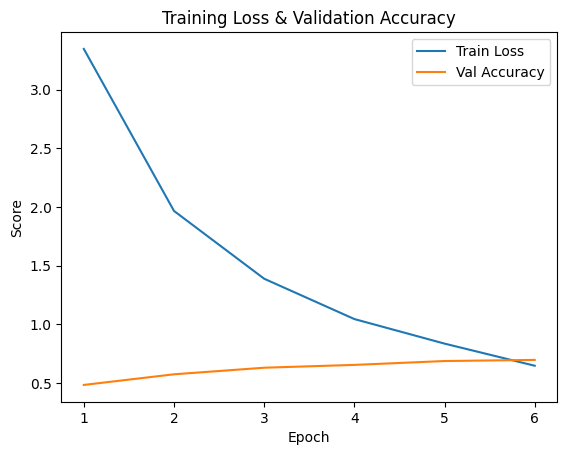

In [47]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(train_losses)+1)
plt.plot(epochs_range, train_losses, label='Train Loss')
plt.plot(epochs_range, val_accuracies, label='Val Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Training Loss & Validation Accuracy")
plt.legend()
plt.show()


In [48]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [49]:
test_df = df[df['split_folder'] == 'test'].reset_index(drop=True)


In [50]:
from torchvision import transforms
tensor_transform = transforms.ToTensor()

class PlantTestDataset(Dataset):
    def __init__(self, df):
        self.df = df
        self.transform = transforms.Compose([
        transforms.Resize((224,224)),  # if needed for your model
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])


    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img = Image.open(self.df.iloc[idx]['image_path']).convert("RGB")  # always convert to RGB
        img = self.transform(img)  # convert PIL to torch.Tensor

        label = self.df.iloc[idx]['disease_idx']  # or 'Disease' for string labels
        return img, label


In [51]:
test_dataset = PlantTestDataset(test_df)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)


In [52]:
print(test_df.columns)


Index(['Name', 'Index', 'Plant', 'Disease', 'Resolution', 'Label file',
       'Mask ratio', 'URL', 'License', 'Split', 'split_folder', 'image_path',
       'mask_path', 'disease_idx'],
      dtype='object')


In [53]:
all_labels = []
all_preds = []

for images, labels in test_loader:
    # If your Dataset returns PIL images, convert to tensor. If already tensor, skip conversion.
    if isinstance(images[0], Image.Image):
        from torchvision import transforms
        tensor_transform = transforms.ToTensor()
        images = torch.stack([tensor_transform(img) for img in images])
    
    images = images.to(device)
    
    # Ensure labels are torch tensors
    if not isinstance(labels, torch.Tensor):
        labels = torch.tensor(labels)
    
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

    all_labels.extend(labels.cpu().numpy().tolist())
    all_preds.extend(predicted.cpu().numpy().tolist())


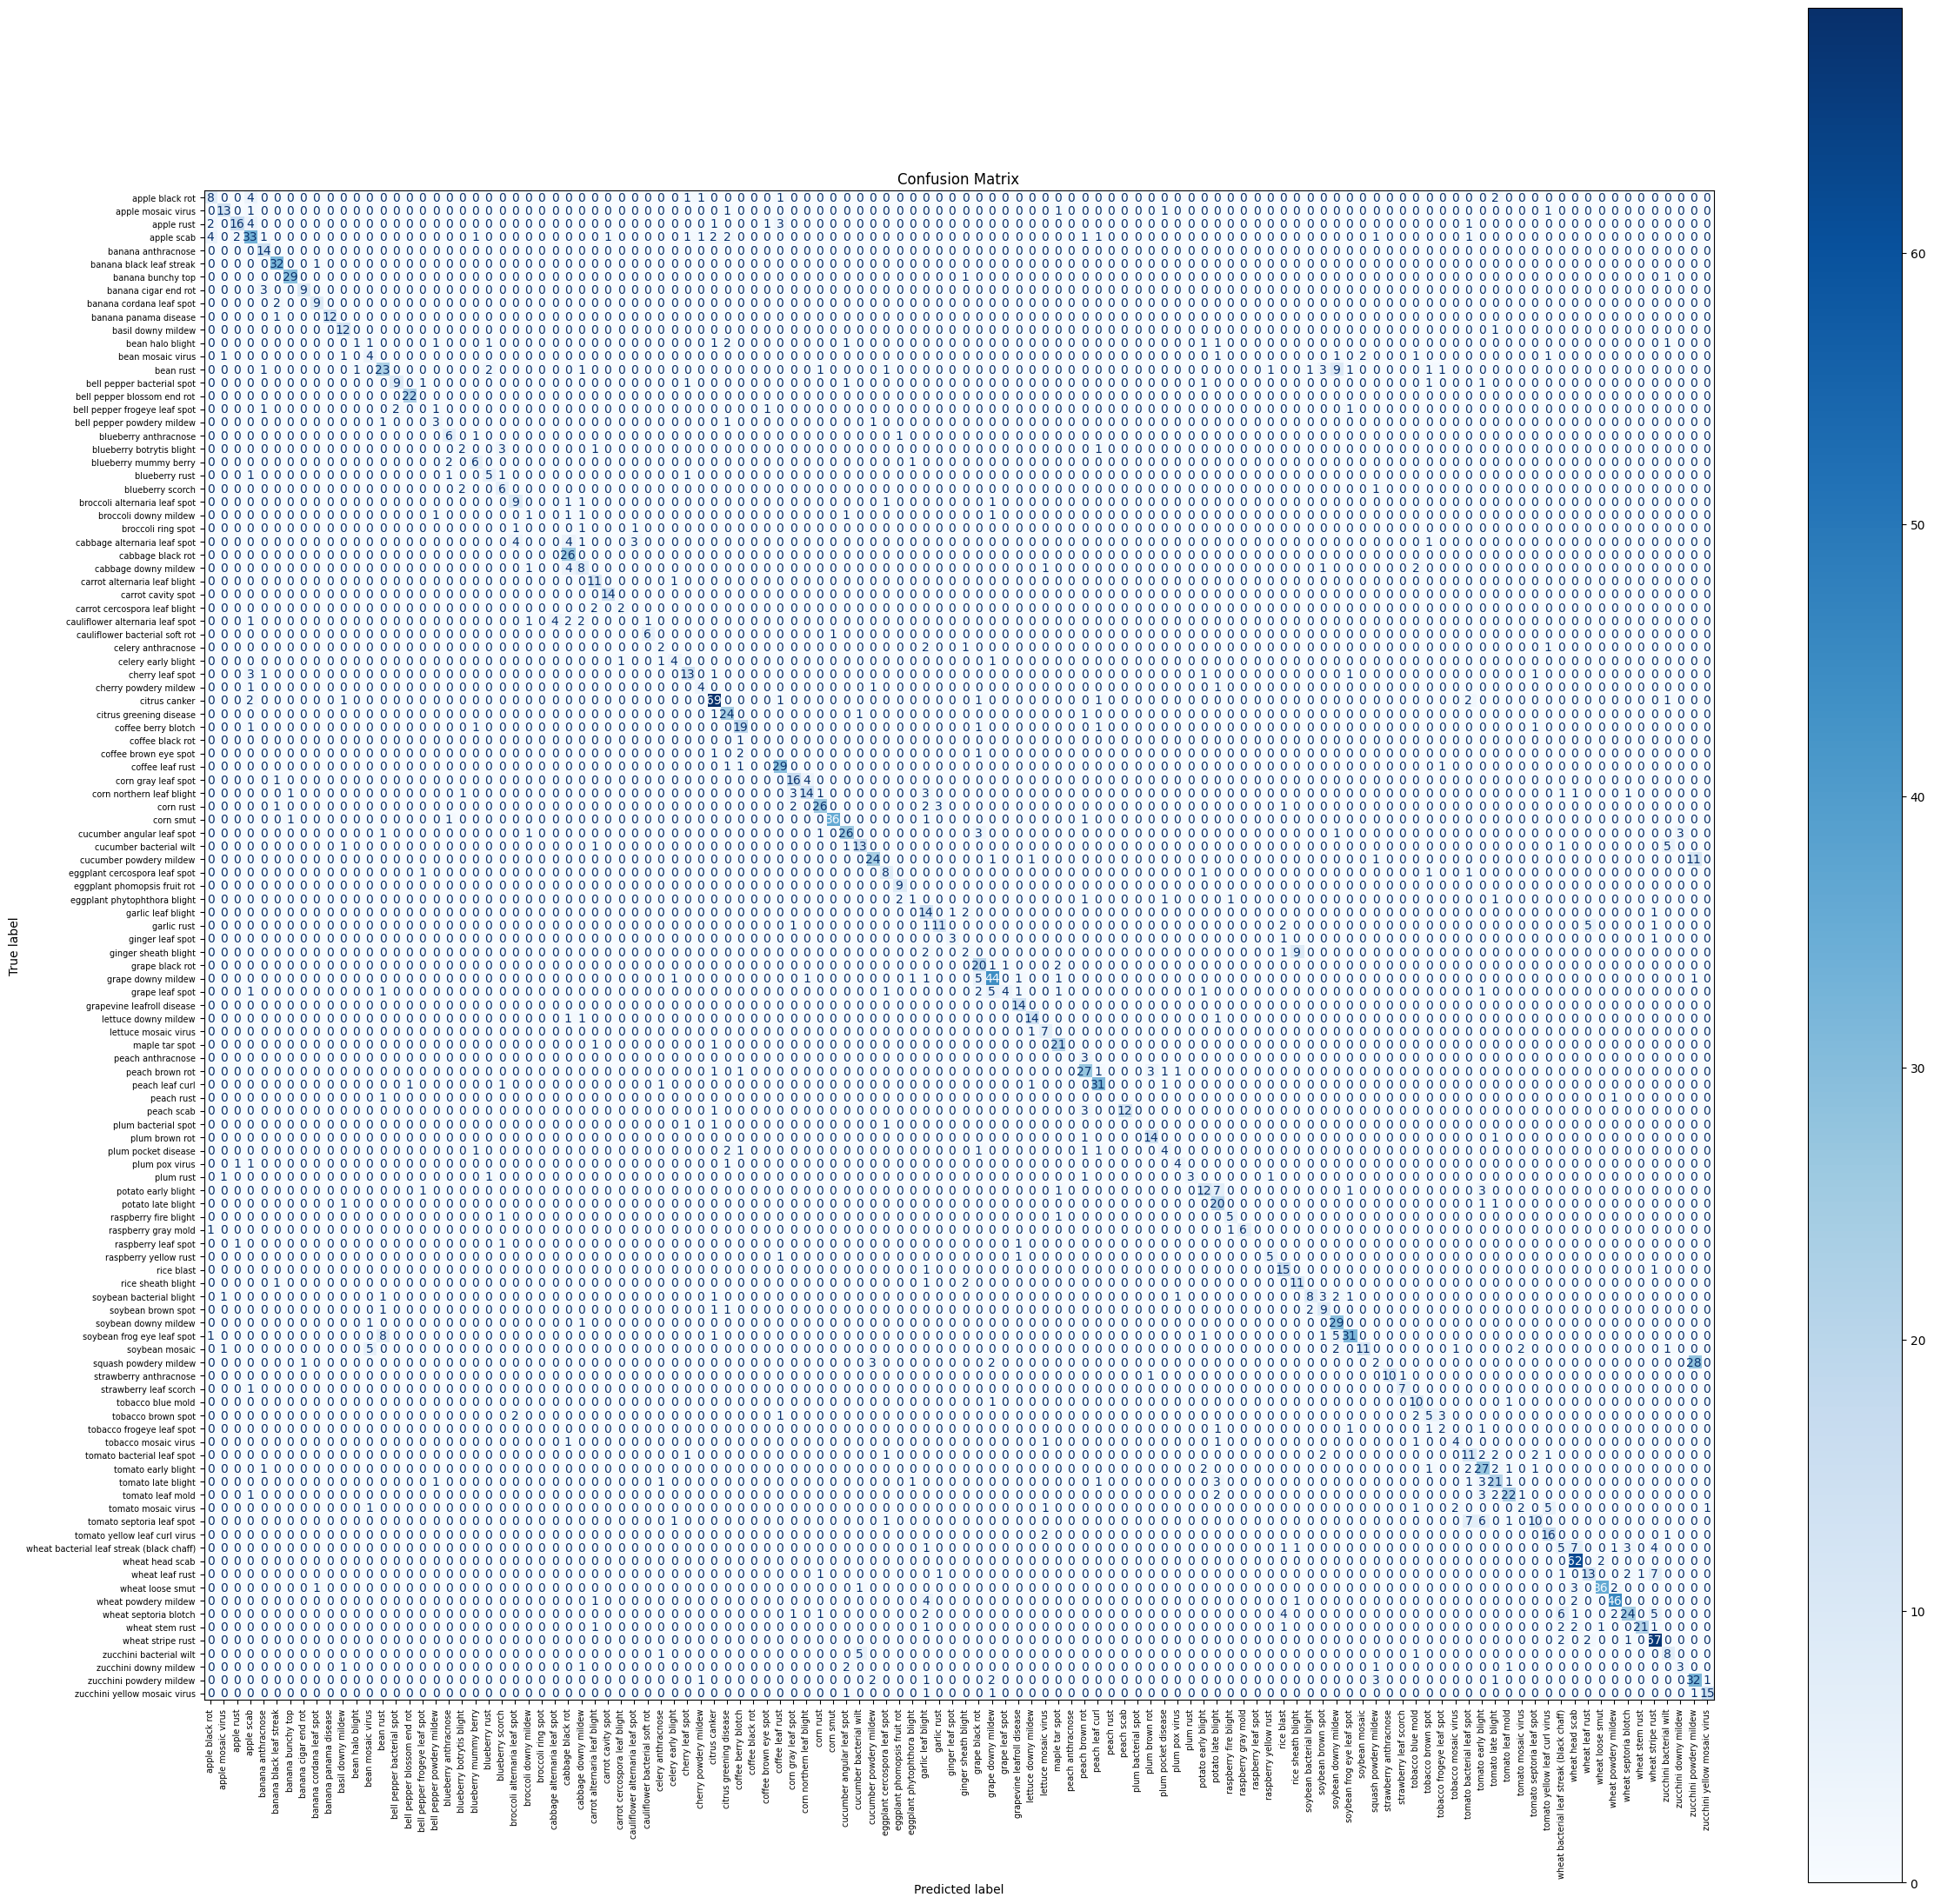

In [54]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get class names in correct index order
disease_classes = test_df.sort_values('disease_idx')['Disease'].unique().tolist()

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(28, 28))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=disease_classes)
disp.plot(ax=ax, cmap='Blues', colorbar=True)
plt.xticks(fontsize=7, rotation=90)
plt.yticks(fontsize=7)
plt.title("Confusion Matrix")
plt.show()


In [55]:
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds, target_names=disease_classes))


                                           precision    recall  f1-score   support

                          apple black rot       0.50      0.47      0.48        17
                       apple mosaic virus       0.76      0.72      0.74        18
                               apple rust       0.80      0.57      0.67        28
                               apple scab       0.60      0.63      0.62        52
                       banana anthracnose       0.64      1.00      0.78        14
                 banana black leaf streak       0.84      0.97      0.90        33
                        banana bunchy top       0.94      0.94      0.94        31
                     banana cigar end rot       0.90      0.75      0.82        12
                 banana cordana leaf spot       0.82      0.82      0.82        11
                    banana panama disease       1.00      0.92      0.96        13
                       basil downy mildew       0.71      0.92      0.80        13
   

C:\Users\mahit\anaconda3\envs\torch_env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\mahit\anaconda3\envs\torch_env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\mahit\anaconda3\envs\torch_env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

In [56]:
import torch.nn as nn

class SimpleUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(SimpleUNet, self).__init__()
        self.encoder1 = nn.Sequential(
            nn.Conv2d(in_channels, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU()
        )
        self.pool1 = nn.MaxPool2d(2)
        self.encoder2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU()
        )
        self.pool2 = nn.MaxPool2d(2)
        self.bottleneck = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.ReLU()
        )
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.decoder2 = nn.Sequential(
            nn.Conv2d(256, 128, 3, padding=1), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU()
        )
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.decoder1 = nn.Sequential(
            nn.Conv2d(128, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU()
        )
        self.final = nn.Conv2d(64, out_channels, 1)

    def forward(self, x):
        enc1 = self.encoder1(x)
        enc2 = self.encoder2(self.pool1(enc1))
        bottleneck = self.bottleneck(self.pool2(enc2))
        dec2 = self.decoder2(torch.cat([self.up2(bottleneck), enc2], 1))
        dec1 = self.decoder1(torch.cat([self.up1(dec2), enc1], 1))
        return torch.sigmoid(self.final(dec1))


In [57]:
device = torch.device('cpu')  # Use 'cuda' if you have GPU

model = SimpleUNet(in_channels=3, out_channels=1)  # out_channels=1 for binary masks
model = model.to(device)


In [58]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9124069..2.64].


Image batch shape: torch.Size([8, 3, 256, 256])
Mask batch shape: torch.Size([8, 1, 256, 256])
Labels: tensor([ 38,  75,  88,  61,  27, 105,  23,  15])
Mask unique values in batch: tensor([0., 1.])
Mask sums in batch: tensor([ 4395.,   344., 27265., 30428.,  7014.,  5307.,  3118.,  2477.])


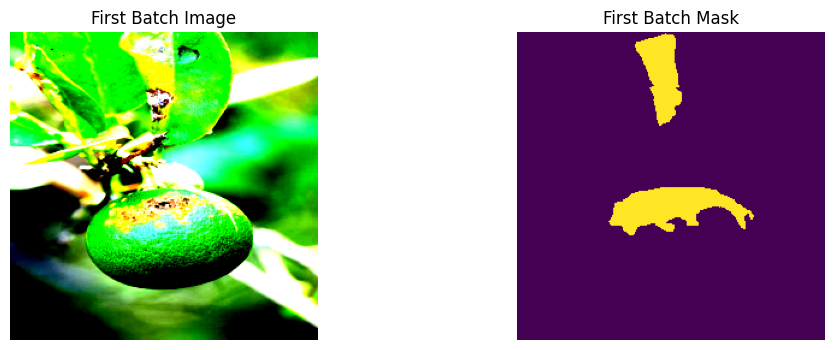

In [59]:
# Your data preparation
train_dataset = PlantSegmentationDataset(train_df)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

# Batch sanity check here
images, masks, labels = next(iter(train_loader))
print("Image batch shape:", images.shape)
print("Mask batch shape:", masks.shape)
print("Labels:", labels)
print("Mask unique values in batch:", masks.unique())
print("Mask sums in batch:", masks.sum(dim=(1,2,3)))

import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.imshow(images[0].permute(1,2,0).cpu())
plt.title("First Batch Image")
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(masks[0][0].cpu())
plt.title("First Batch Mask")
plt.axis('off')
plt.show()


In [ ]:
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

def dice_score(pred, target, threshold=0.5):
    pred = (pred > threshold).float()
    intersection = (pred * target).sum(dim=(1,2,3))
    union = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3))
    dice = (2. * intersection) / (union + 1e-7)
    return dice.mean().item()

num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for images, masks, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images = images.to(device)
        masks = masks.to(device).float()
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()        
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)
    print(f"Epoch {epoch+1}, Train Loss: {avg_loss:.4f}")
    
    # Validation Dice computation
    model.eval()
    val_dice = 0
    batch_count = 0
    first_batch_images, first_batch_masks, first_batch_outputs = None, None, None
    with torch.no_grad():
        for batch_idx, (val_images, val_masks, val_labels) in enumerate(val_loader):
            val_images = val_images.to(device)
            val_masks = val_masks.to(device)
            val_outputs = model(val_images)
            val_dice += dice_score(val_outputs, val_masks)
            batch_count += 1
            if batch_idx == 0:  # Save first batch for visualization
                first_batch_images = val_images.cpu()
                first_batch_masks = val_masks.cpu()
                first_batch_outputs = (val_outputs > 0.5).cpu()
    print(f"Epoch {epoch+1}, Validation Dice: {val_dice/batch_count:.4f}")
    
    # Visualization: Input, True Mask, Predicted Mask (first val batch)
    num_show = min(3, first_batch_images.shape[0])
    for i in range(num_show):
        plt.figure(figsize=(12,4))
        plt.subplot(1,3,1)
        plt.imshow(first_batch_images[i].permute(1,2,0))
        plt.title('Val Image')
        plt.axis('off')
        plt.subplot(1,3,2)
        plt.imshow(first_batch_masks[i][0])
        plt.title('True Mask')
        plt.axis('off')
        plt.subplot(1,3,3)
        plt.imshow(first_batch_outputs[i][0])
        plt.title('Predicted Mask')
        plt.axis('off')
        plt.show()


In [61]:
# Save only after training finishes
torch.save(model.state_dict(), "seg_class_best_model.pt")


In [62]:
model_unet = SimpleUNet()
model_unet.load_state_dict(torch.load('seg_class_best_model.pt'))
model_unet = model_unet.to(device)

In [63]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_classes = len(df['disease_idx'].unique()) # Number of disease classes

# EfficientNet-B0 with custom output layer
model_efficientnet = models.efficientnet_b0(weights='EfficientNet_B0_Weights.IMAGENET1K_V1')
model_efficientnet.classifier[1] = nn.Linear(model_efficientnet.classifier[1].in_features, num_classes)
model_efficientnet = model_efficientnet.to(device)


In [64]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_efficientnet.parameters(), lr=1e-4)

# train_loader and val_loader: yield (images, labels) where images are [B, 3, H, W], labels are class indices


In [65]:
from tqdm import tqdm

num_epochs = 5 # your number of epochs
for epoch in range(num_epochs):
    model_efficientnet.train()
    train_loss = 0.0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=False)
    for images, _, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_efficientnet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        progress_bar.set_postfix(loss=loss.item())
    
    # Average training loss for the epoch (if desired)
    train_loss /= len(train_loader.dataset)

    # Optionally: run validation and print metrics
    model_efficientnet.eval()
    correct = total = 0
    with torch.no_grad():
        for images,_, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_efficientnet(images)
            _, predicted = outputs.max(dim=1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    val_acc = correct / total
    print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f} | Val Acc = {val_acc:.4f}")


Epoch 1: Train Loss = 3.3513 | Val Acc = 0.4908


Epoch 2: Train Loss = 1.9600 | Val Acc = 0.5934


Epoch 3: Train Loss = 1.3883 | Val Acc = 0.6536


Epoch 4: Train Loss = 1.0698 | Val Acc = 0.6752


Epoch 5: Train Loss = 0.8261 | Val Acc = 0.6784


In [66]:
torch.save(model_efficientnet.state_dict(), 'efficientnet_classifier.pt')


In [67]:
print(df.columns)


Index(['Name', 'Index', 'Plant', 'Disease', 'Resolution', 'Label file',
       'Mask ratio', 'URL', 'License', 'Split', 'split_folder', 'image_path',
       'mask_path', 'disease_idx'],
      dtype='object')


In [68]:
# Assuming you have access to your dataset dataframe 'df'
# Map class indices to class names (string labels)
class_names = df['Disease'].unique()  # or the column with disease names
class_indices = df['disease_idx'].unique()

# Sort indices to maintain order
class_indices.sort()

# Create dict from index to disease name
class_dict = {idx: class_names[i] for i, idx in enumerate(class_indices)}

print(class_dict)


{np.int64(0): 'apple black rot', np.int64(1): 'apple mosaic virus', np.int64(2): 'apple rust', np.int64(3): 'apple scab', np.int64(4): 'banana anthracnose', np.int64(5): 'banana black leaf streak', np.int64(6): 'banana bunchy top', np.int64(7): 'banana cigar end rot', np.int64(8): 'banana cordana leaf spot', np.int64(9): 'banana panama disease', np.int64(10): 'basil downy mildew', np.int64(11): 'bean halo blight', np.int64(12): 'bean mosaic virus', np.int64(13): 'bean rust', np.int64(14): 'bell pepper bacterial spot', np.int64(15): 'bell pepper blossom end rot', np.int64(16): 'bell pepper frogeye leaf spot', np.int64(17): 'bell pepper powdery mildew', np.int64(18): 'blueberry anthracnose', np.int64(19): 'blueberry botrytis blight', np.int64(20): 'blueberry mummy berry', np.int64(21): 'blueberry rust', np.int64(22): 'blueberry scorch', np.int64(23): 'broccoli alternaria leaf spot', np.int64(24): 'broccoli downy mildew', np.int64(25): 'broccoli ring spot', np.int64(26): 'cabbage alternar

Using cache found in C:\Users\mahit/.cache\torch\hub\pytorch_vision_v0.15.2
C:\Users\mahit\anaconda3\envs\torch_env\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\mahit\anaconda3\envs\torch_env\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Predicted disease class: wheat stripe rust


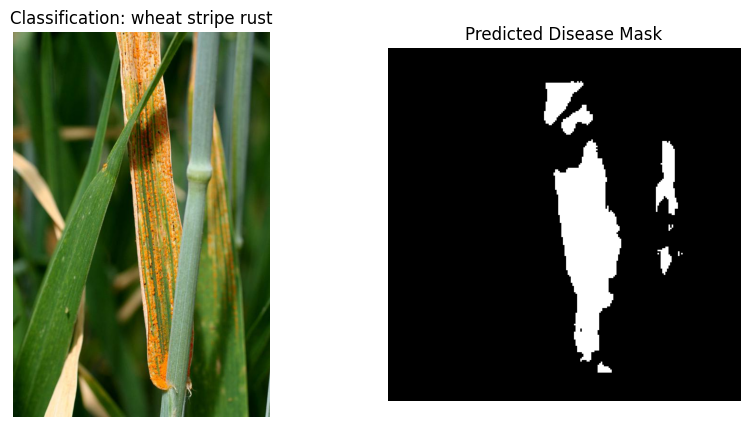

In [69]:
from tkinter import Tk, filedialog
from PIL import Image
import torch
import matplotlib.pyplot as plt
from torchvision import transforms

# Define your transforms (keep consistent with training)
image_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load UNet (segmentation) model
model_unet = SimpleUNet()  # replace with your UNet class import
model_unet.load_state_dict(torch.load('seg_class_best_model.pt'))
model_unet.to(device)
model_unet.eval()

# Load EfficientNet (classification) model
num_classes = len(df['disease_idx'].unique())  # Your number of classes
model_efficientnet = torch.hub.load('pytorch/vision:v0.15.2', 'efficientnet_b0', pretrained=False)
model_efficientnet.classifier[1] = torch.nn.Linear(model_efficientnet.classifier[1].in_features, num_classes)
model_efficientnet.load_state_dict(torch.load('efficientnet_classifier.pt'))
model_efficientnet.to(device)
model_efficientnet.eval()

# Map class indices to disease names for classification output
#class_dict = {0: 'Disease A', 1: 'Disease B', 2: 'Disease C'}  # Replace with your mapping

# File dialog to select image
root = Tk()
root.withdraw()
file_path = filedialog.askopenfilename(title='Select Image',
                                       filetypes=[('Image Files', '*.jpg *.jpeg *.png *.bmp')])
root.destroy()

if file_path:
    img = Image.open(file_path).convert('RGB')
    img_t = image_transforms(img).unsqueeze(0).to(device)

    # UNet prediction
    with torch.no_grad():
        pred_mask = model_unet(img_t)
        pred_mask_bin = (pred_mask > 0.5).float().cpu().squeeze(0)  # threshold mask

    # EfficientNet prediction
    with torch.no_grad():
        class_logits = model_efficientnet(img_t)
        pred_class = class_logits.argmax(dim=1).item()
        pred_class_name = class_dict.get(pred_class, "Unknown")

    print("Predicted disease class:", pred_class_name)

    # Visualization
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title(f"Classification: {pred_class_name}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(pred_mask_bin[0], cmap='gray')
    plt.title("Predicted Disease Mask")
    plt.axis('off')

    plt.show()

else:
    print("No file selected.")
